# Table of contents

* **Introduction**
* **Objective**
* **Gated Recurrent Unit (GRU) Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environment**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training**
    * Model architecture, model building, and model training (Keras)
    * Model Training (Keras)
    * Model architecture, model building, and model training (TensorFlow custom functions)
    * Model Training (TensorFlow custom function)
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

This tutorial establishes a comprehensive pipeline for multivariate time series forecasting utilizing the Gated Recurrent Unit (GRU) architecture within the TensorFlow 2.x and Keras framework. The project focuses on predicting the next day's financial features from a single stock, EQIX, drawn from the NYSE price dataset. The core novelty lies in presenting two modeling methodologies: the efficient use of standard Keras $\mathbf{GRU}$ layers and the architectural encapsulation of the recurrent stack into a custom Keras Layer. This design choice demonstrates advanced modularity, which is crucial for building complex, reusable deep learning components. The prediction task is sequence-to-one, where a 30-day window of historical data is used to forecast the state of the features on the 31st day.

# Objective

The primary aim is the development of a sequence-to-sequence time series model, where the sequence consists of multiple input features. This includes:

- Constructing and comparing a standard Keras $\mathbf{GRU}$ model against a custom implementation that combines $\mathbf{LayerNormalization}$ with a stack of $\mathbf{GRU}$ units.
- Implementing a robust data preprocessing pipeline tailored for chronological time series data, encompassing feature engineering and scaling.
- Training the recurrent models using advanced techniques like the $\mathbf{Adam}$ optimizer and $\mathbf{EarlyStopping}$ to ensure optimal convergence and prevent overfitting.
- Evaluating the final models using both magnitude-based regression metrics (MSE) and a specialized directional accuracy metric essential for financial applications.

# Gated Recurrent Unit (GRU) Foundations

The Gated Recurrent Unit (GRU) is a sophisticated form of Recurrent Neural Network (RNN) designed specifically to address the fundamental problems of training standard RNNs on long sequences. The GRU, introduced by Cho et al. in 2014, shares a structure and objective similar to the Long Short-Term Memory (LSTM) network but uses fewer parameters and is computationally less complex.

**The Vanishing Gradient Problem**

Standard RNNs suffer from the vanishing gradient problem when processing long sequences. During Backpropagation Through Time (BPTT), gradients (error signals) are multiplied across numerous time steps. If these gradients are small, the repeated multiplication causes the signal to shrink exponentially, becoming effectively zero before reaching the early layers of the network. Consequently, the network fails to learn long-term dependencies, meaning it struggles to relate information at the start of a sequence to events much later.

**GRU Architecture: Gating Mechanisms**

The GRU overcomes the vanishing gradient problem by incorporating gating mechanisms that regulate the flow of information and control what content is stored in, or discarded from, the hidden state. Unlike the LSTM, which uses three gates (input, forget, and output), the GRU uses only two: the Update Gate and the Reset Gate .

**1. The Reset Gate ($\mathbf{r}_t$)**

The reset gate determines how much of the previous hidden state ($\mathbf{h}_{t-1}$) is relevant to the computation of the current time step's candidate hidden state ($\mathbf{\tilde{h}}_t$).

- Function: It is a vector of values between $\mathbf{0}$ and $\mathbf{1}$, typically calculated using the current input ($\mathbf{x}_t$) and the previous hidden state ($\mathbf{h}_{t-1}$), passed through a sigmoid activation function ($\sigma$).
- Concept: A value close to $\mathbf{0}$ means the previous hidden state should be "forgotten," effectively making the current candidate hidden state dependent only on the current input. This mechanism allows the GRU to clear irrelevant information that has been stored long ago, enhancing its ability to adapt quickly to new patterns.

**2. The Update Gate ($\mathbf{z}_t$)**

The update gate controls the degree to which the new candidate hidden state ($\mathbf{\tilde{h}}_t$) should overwrite the previous hidden state ($\mathbf{h}_{t-1}$). It acts as a combined forget and input gate from the LSTM structure.
- Function: Like the reset gate, it is a vector of values between $\mathbf{0}$ and $\mathbf{1}$, also using a sigmoid activation.

**Concept:**

- A value close to $\mathbf{1}$ indicates that the previous hidden state is highly relevant and should be retained in the new hidden state. The network "remembers" the old state.
- A value close to $\mathbf{0}$ indicates that the previous hidden state should be forgotten and largely replaced by the new candidate hidden state. The network "forgets" the old state and "updates" with the new information.

**3. The Hidden State $\mathbf{h}_t$**

The hidden state ($\mathbf{h}_t$) is the core memory unit of the GRU. It is a linear combination of the previous hidden state ($\mathbf{h}_{t-1}$) and the new candidate hidden state ($\mathbf{\tilde{h}}_t$), weighted by the update gate ($\mathbf{z}_t$).
- Candidate Hidden State ($\mathbf{\tilde{h}}_t$): This state represents the potential new memory content based on the current input and a reset version of the previous hidden state. The reset gate's output is multiplied element-wise with $\mathbf{h}_{t-1}$ before passing it through a $\mathbf{tanh}$ activation function.
- Final Hidden State: The final hidden state is determined by the update gate:


$$\mathbf{h}_t = (\mathbf{1} - \mathbf{z}_t) \odot \mathbf{h}_{t-1} + \mathbf{z}_t \odot \mathbf{\tilde{h}}_t$$


The update gate ($\mathbf{z}_t$) regulates the balance: a high $\mathbf{z}_t$ includes more of the new content ($\mathbf{\tilde{h}}_t$), while a low $\mathbf{z}_t$ retains more of the past memory ($\mathbf{h}_{t-1}$).

**Advantages of the GRU**

- Efficiency: The GRU has only two gates and lacks the separate cell state found in the LSTM. This streamlined structure reduces the number of parameters, resulting in faster training times and requiring less computational overhead.
- Long-Term Dependency Learning: The gating mechanism, particularly the update gate, allows the network to bypass short-term time steps and carry relevant information forward across hundreds of time steps, thus effectively solving the vanishing gradient problem.
- Performance: Despite its simpler architecture, the GRU often achieves performance comparable to the more complex LSTM in many sequence modeling tasks, including time series forecasting, natural language processing, and speech recognition.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Field Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">date</td>
    <td class="tg-7zrl">The date range for each data entry. This appears to be a combined string of start and end dates.</td>
    <td class="tg-7zrl">Text</td>
  </tr>
  <tr>
    <td class="tg-7zrl">DateTimeCount</td>
    <td class="tg-7zrl">The count of DateTime entries within the specified date range.</td>
    <td class="tg-7zrl">Numeric (Integer)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">symbol</td>
    <td class="tg-7zrl">An identifier or code, possibly for a financial instrument or category.</td>
    <td class="tg-7zrl">Text</td>
  </tr>
  <tr>
    <td class="tg-7zrl">open</td>
    <td class="tg-7zrl">The opening price/value for a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">close</td>
    <td class="tg-7zrl">The closing price/value for a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">low</td>
    <td class="tg-7zrl">The lowest price/value recorded within a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">high</td>
    <td class="tg-7zrl">The highest price/value recorded within a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">volume</td>
    <td class="tg-7zrl">The trading volume (number of units traded) within a given period.</td>
    <td class="tg-7zrl">Numeric (Integer)</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/dgawlik/nyse)**

# Pipeline Overview

The forecasting system follows a linear progression through distinct computational stages, ensuring data integrity and model rigor:
- Data Ingestion and Filtering: Load the NYSE price data, isolate the target stock (EQIX), and prepare the chronological sequence.
- Chronological Data Splitting: Partition the data into three sets—Train, Validation, and Test—maintaining the original time order to simulate real-world forecasting.
- Feature Transformation: Engineer new temporal features and eliminate irrelevant identifiers.
- MinMax Scaling: Apply feature normalization based exclusively on the training set statistics to prevent data leakage.
- Sequence Creation: Transform the flat time series into fixed-length $\mathbf{(sequence\_length, features)}$ input tensors and corresponding single-step target vectors.
- TensorFlow Conversion: Convert the processed sequences into high-performance $\mathbf{tf.Tensor}$ objects for efficient GPU processing.
- Model Definition: Construct both the standard and custom $\mathbf{GRU}$ stack architectures.
- Model Training: Compile and fit the model using the Mean Squared Error loss and early stopping.
- Evaluation and Visualization: Generate full-timeline predictions and compute performance metrics.

# Approach

**Preprocess Pipeline Approach**

Data preparation is executed rigorously to maintain temporal separation and numerical stability:

- Data Separation: The entire dataset is first sorted by date. A strict chronological separation (e.g., 80% for initial partitioning) is applied before any other transformation. The target stock (EQIX) is then filtered from both the training and test partitions.
- Feature Engineering: The explicit date column is parsed to extract auxiliary features, such as $\mathbf{year}$ and $\mathbf{month}$, which provide the recurrent network with cyclical temporal context. Irrelevant columns are subsequently dropped.
- Normalization: A `MinMaxScaler` is instantiated and fitted only on the numerical features of the training set. This fitted scaler is then applied to transform the training, validation, and test sets. This critical step ensures that the model cannot access the range of values present in future data, which would compromise the validity of the evaluation (data leakage).
- Sliding Window Transformation: The time series is restructured into a three-dimensional array (`samples, sequence_length, features`). A sequence length (`seq_len`) of 30 days is chosen. For each window $\mathbf{X}$, the corresponding target $\mathbf{y}$ is the feature vector immediately following the window. The sequences derived from the training set are further split into the training and validation sequences.
- Final Tensor Conversion: All NumPy arrays are converted to `tf.float32` tensors, preparing them for the Keras `fit` process.

**Model Training Approach**

The training methodology emphasizes both architectural clarity and effective regularization:

- Architecture Details: Both the standard and custom models utilize 128 units per $\mathbf{GRU}$ layer, with a stack of three $\mathbf{GRU}$ layers to extract complex temporal hierarchies. $\mathbf{Dropout}$ ($\mathbf{0.2}$) is applied to the inputs of the recurrent layers to regularize the network and mitigate cell co-adaptation. The output of the final $\mathbf{GRU}$ layer is passed through a $\mathbf{Dense}$ layer with seven units, matching the number of features in the target vector.
- Custom Layer Implementation: The `CustomGRUStack` original from `tf.keras.layers.Layer`. It internally defines the `LayerNormalization` instance and the $\mathbf{GRU}$ stack. Its $\mathbf{call}$ method enforces the normalization before processing the sequence through the recurrent units. For serialization, the layer implements the `get_config()` method.
- Compilation Strategy: The network is compiled using the $\mathbf{Adam}$ optimizer with a modest learning rate ($\mathbf{0.01}$) to ensure stable convergence. The $\mathbf{MeanSquaredError}$ is selected as the loss function, appropriate for minimizing magnitude deviations in normalized regression targets.
- Optimization Control: Training is capped at 200 epochs but is regulated by $\mathbf{EarlyStopping}$. This callback monitors the `val_loss` and halts training if no improvement is observed after a patience window of 8 epochs. Upon stopping, the best weights corresponding to the minimum validation loss are automatically restored.

**Model Evaluation Approach**

Evaluation confirms the model's fitness for prediction through magnitude and directional analysis:

- Loss Quantification: The model is definitively assessed using the `model.evaluate()` method on the completely independent `x_test_tf` dataset, yielding the final, unbiased Mean Squared Error.
- Prediction Generation: Predictions (`model.predict()`) are generated for all three sets (train, validation, test) to visualize the model's performance throughout the entire time sequence.
- Visualization: A plot is generated comparing the actual normalized feature values against the predicted values for a selected feature (e.g., 'open'). The visualization must clearly delineate the boundaries between the training, validation, and test periods. A second plot provides a zoomed-in view of the critical future $\mathbf{Test}$ period.
- Directional Accuracy: A custom metric calculates the Correct Sign Prediction Correlation. This involves checking if the predicted change (e.g., predicted close - predicted open) matches the sign of the actual change (actual close - actual open). The accuracy is reported as a fraction for each of the three datasets.

# Setup Environment

**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import math
import sklearn
import sklearn.preprocessing
import datetime
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import warnings
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore", category=FutureWarning, module='seaborn._oldcore')

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

2026-03-24 16:48:34.917296: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774370915.133657      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774370915.195319      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.18.0
Keras Version: 3.8.0


# Data Loading

The process begins with loading the New York Stock Exchange (NYSE) data, which contains various features for multiple stocks over time. The primary challenge in time series analysis is maintaining the chronological integrity of the data to accurately simulate real-world forecasting.

In [2]:
df = pd.read_csv('/kaggle/input/nyse/prices-split-adjusted.csv')
df.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


**Train and Test Split**

The dataset is initially loaded, and its sheer size necessitates an efficient chronological split into training (80%) and testing (20%) subsets. The data must be sorted strictly by the $\mathbf{date}$ column before splitting. This non-randomized partitioning ensures the training process uses only historical information, and the test set represents the genuinely unseen future data. Violating this constraint would lead to data leakage, resulting in an overly optimistic and unreliable model evaluation. The shapes of the resulting subsets confirm the non-random, time-based division.

In [3]:
df = df.sort_values(by='date', ascending=True).reset_index(drop=True)

test_size_ratio = 0.2 
split_point = int(len(df) * (1 - test_size_ratio))

train = df.iloc[:split_point].copy()
test = df.iloc[split_point:].copy()

print("\nData split chronologically by 'date' column:")
print(f"Train DataFrame shape: {train.shape}")
print(f"Test DataFrame shape: {test.shape}")


Data split chronologically by 'date' column:
Train DataFrame shape: (681011, 7)
Test DataFrame shape: (170253, 7)


In [4]:
train = train.sort_values(by='date').reset_index(drop=True)
test = test.sort_values(by='date').reset_index(drop=True)

**Stock Selection and Filtering**

For concentrated, single-series modeling, the data is filtered to isolate only the records corresponding to the target stock, $\mathbf{EQIX}$. Focusing on a single ticker simplifies the initial multivariate modeling problem, ensuring that the recurrent model learns the specific temporal patterns and volatility characteristics unique to that equity.

In [5]:
train = train[train.symbol == 'EQIX'].copy()
test = test[test.symbol == 'EQIX'].copy()

train = train.sort_values(by='date').reset_index(drop=True)
test = test.sort_values(by='date').reset_index(drop=True)
train

,date,symbol,open,close,low,high,volume
0,2010-01-04,EQIX,106.519997,109.559998,106.510002,109.620003,576300.0
1,2010-01-05,EQIX,109.589996,108.540001,108.379997,109.589996,681900.0
2,2010-01-06,EQIX,108.949997,109.529999,108.220001,110.570000,1397500.0
3,2010-01-07,EQIX,109.250000,107.290001,106.639999,110.349998,797200.0
4,2010-01-08,EQIX,106.800003,106.769997,105.900002,107.279999,432400.0
...,...,...,...,...,...,...,...
1417,2015-08-20,EQIX,284.220001,279.959991,279.920013,284.649994,568700.0
1418,2015-08-21,EQIX,277.160004,271.309998,271.309998,279.790009,1271900.0
1419,2015-08-24,EQIX,260.000000,255.529999,251.000000,267.089996,1306700.0
1420,2015-08-25,EQIX,260.309998,251.110001,250.860001,263.670013,1294200.0


# Exploratory Data Analysis (EDA)

Exploratory analysis provides critical insights into data trends, volatility, and the internal relationships between features, informing the subsequent feature engineering and model design phases.

**Basic Information**

In [6]:
train.head()

,date,symbol,open,close,low,high,volume
0,2010-01-04,EQIX,106.519997,109.559998,106.510002,109.620003,576300.0
1,2010-01-05,EQIX,109.589996,108.540001,108.379997,109.589996,681900.0
2,2010-01-06,EQIX,108.949997,109.529999,108.220001,110.570000,1397500.0
3,2010-01-07,EQIX,109.250000,107.290001,106.639999,110.349998,797200.0
4,2010-01-08,EQIX,106.800003,106.769997,105.900002,107.279999,432400.0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1422 entries, 0 to 1421
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1422 non-null   object 
 1   symbol  1422 non-null   object 
 2   open    1422 non-null   float64
 3   close   1422 non-null   float64
 4   low     1422 non-null   float64
 5   high    1422 non-null   float64
 6   volume  1422 non-null   float64
dtypes: float64(5), object(2)
memory usage: 77.9+ KB


In [8]:
train.describe()

,open,close,low,high,volume
count,1422.000000,1422.000000,1422.000000,1422.000000,1.422000e+03
mean,160.671779,160.734803,158.748868,162.544423,9.128723e+05
std,57.769144,57.761722,57.255626,58.169847,1.064773e+06
min,71.750000,70.339996,69.419998,74.510002,1.524000e+05
25%,98.382502,98.502500,97.042500,99.649997,5.338000e+05
50%,173.614998,173.385002,170.770004,176.120003,7.309500e+05
75%,210.034996,210.097504,208.022495,212.072502,1.040200e+06
max,286.130005,287.420013,283.980011,288.500000,3.057420e+07


**Feature Trends and Stationarity**

The price features ($\mathbf{open, close, low, high}$) display a strong upward, non-stationary trend over the observation period, reflecting significant capital appreciation. The lines remain tightly grouped, indicating low intraday volatility in most periods. The $\mathbf{volume}$ feature, however, is characterized by large, intermittent spikes, suggesting irregular trading activity driven by news or corporate events. Time series models must account for these non-stationary trends and volatility bursts.

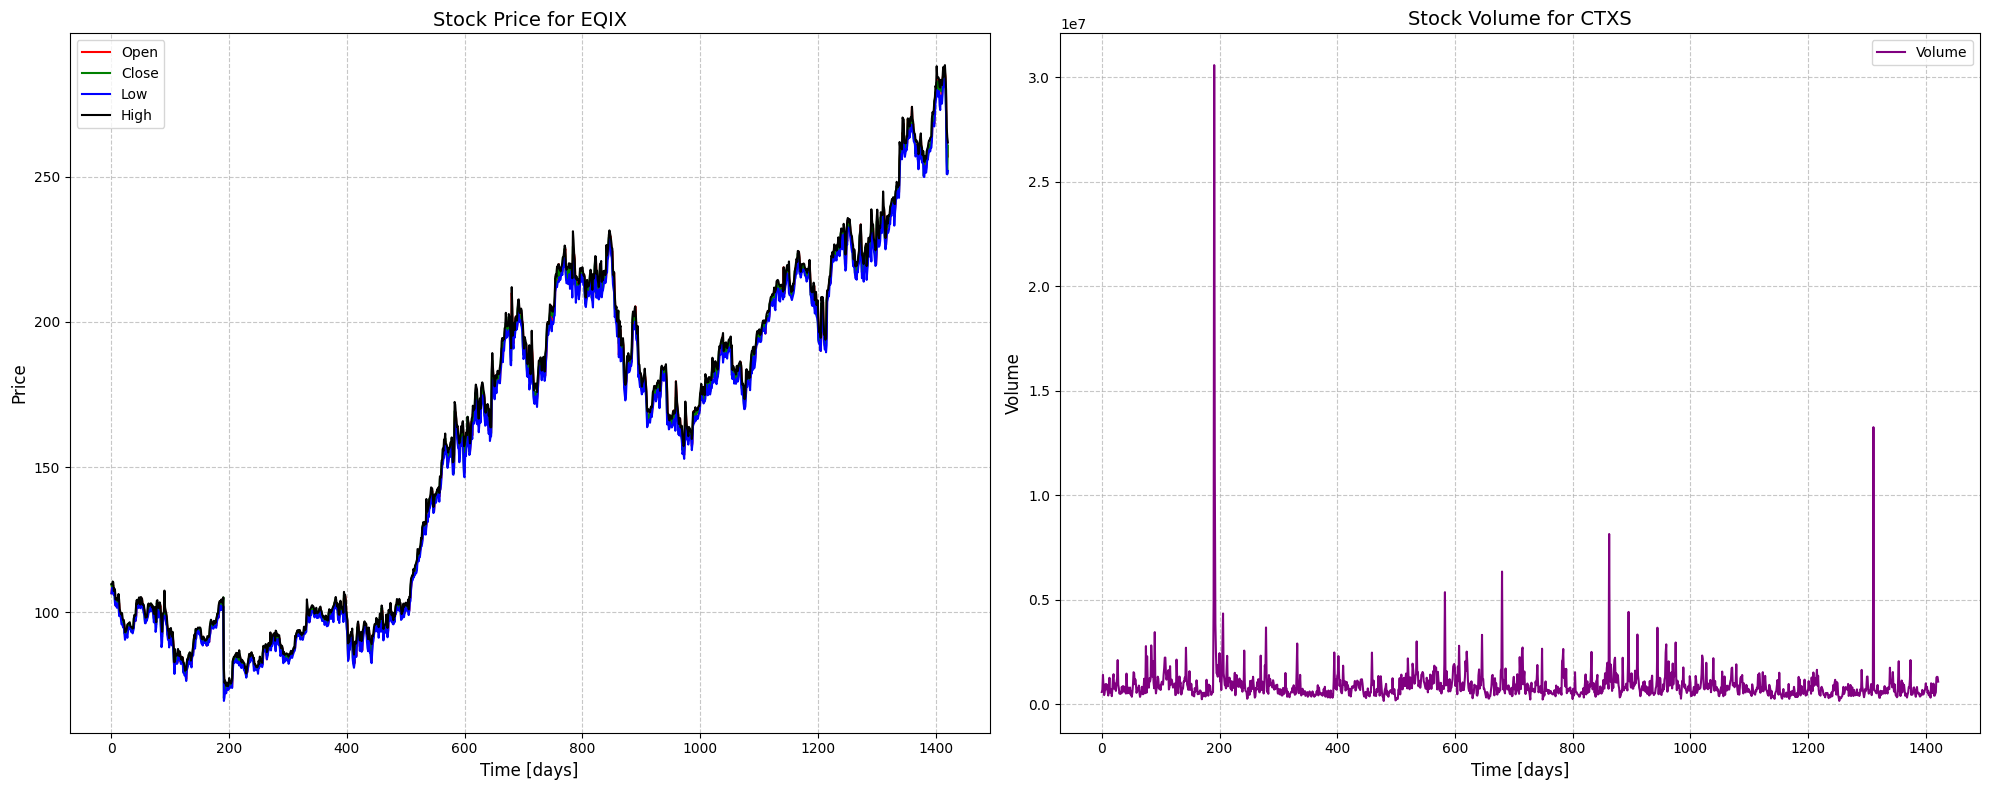

In [9]:
train['time_idx'] = range(len(train))

ctxs_data = train[train.symbol == 'EQIX']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.lineplot(x='time_idx', y='open', data=ctxs_data, color='red', label='Open', ax=axes[0])
sns.lineplot(x='time_idx', y='close', data=ctxs_data, color='green', label='Close', ax=axes[0])
sns.lineplot(x='time_idx', y='low', data=ctxs_data, color='blue', label='Low', ax=axes[0])
sns.lineplot(x='time_idx', y='high', data=ctxs_data, color='black', label='High', ax=axes[0])

axes[0].set_title('Stock Price for EQIX', fontsize=14)
axes[0].set_xlabel('Time [days]', fontsize=12)
axes[0].set_ylabel('Price', fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.lineplot(x='time_idx', y='volume', data=ctxs_data, color='purple', label='Volume', ax=axes[1])

axes[1].set_title('Stock Volume for CTXS', fontsize=14)
axes[1].set_xlabel('Time [days]', fontsize=12)
axes[1].set_ylabel('Volume', fontsize=12)
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Correlation Analysis**

Feature correlation analysis, presented in the heatmap, reveals critical statistical relationships within the time series data.

In [10]:
train = train.drop(columns=['symbol'])
test = test.drop(columns=['symbol'])
train

,date,open,close,low,high,volume,time_idx
0,2010-01-04,106.519997,109.559998,106.510002,109.620003,576300.0,0
1,2010-01-05,109.589996,108.540001,108.379997,109.589996,681900.0,1
2,2010-01-06,108.949997,109.529999,108.220001,110.570000,1397500.0,2
3,2010-01-07,109.250000,107.290001,106.639999,110.349998,797200.0,3
4,2010-01-08,106.800003,106.769997,105.900002,107.279999,432400.0,4
...,...,...,...,...,...,...,...
1417,2015-08-20,284.220001,279.959991,279.920013,284.649994,568700.0,1417
1418,2015-08-21,277.160004,271.309998,271.309998,279.790009,1271900.0,1418
1419,2015-08-24,260.000000,255.529999,251.000000,267.089996,1306700.0,1419
1420,2015-08-25,260.309998,251.110001,250.860001,263.670013,1294200.0,1420


In [11]:
train['date'] = pd.to_datetime(train['date'])

train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train

,date,open,close,low,high,volume,time_idx,year,month,day
0,2010-01-04,106.519997,109.559998,106.510002,109.620003,576300.0,0,2010,1,4
1,2010-01-05,109.589996,108.540001,108.379997,109.589996,681900.0,1,2010,1,5
2,2010-01-06,108.949997,109.529999,108.220001,110.570000,1397500.0,2,2010,1,6
3,2010-01-07,109.250000,107.290001,106.639999,110.349998,797200.0,3,2010,1,7
4,2010-01-08,106.800003,106.769997,105.900002,107.279999,432400.0,4,2010,1,8
...,...,...,...,...,...,...,...,...,...,...
1417,2015-08-20,284.220001,279.959991,279.920013,284.649994,568700.0,1417,2015,8,20
1418,2015-08-21,277.160004,271.309998,271.309998,279.790009,1271900.0,1418,2015,8,21
1419,2015-08-24,260.000000,255.529999,251.000000,267.089996,1306700.0,1419,2015,8,24
1420,2015-08-25,260.309998,251.110001,250.860001,263.670013,1294200.0,1420,2015,8,25


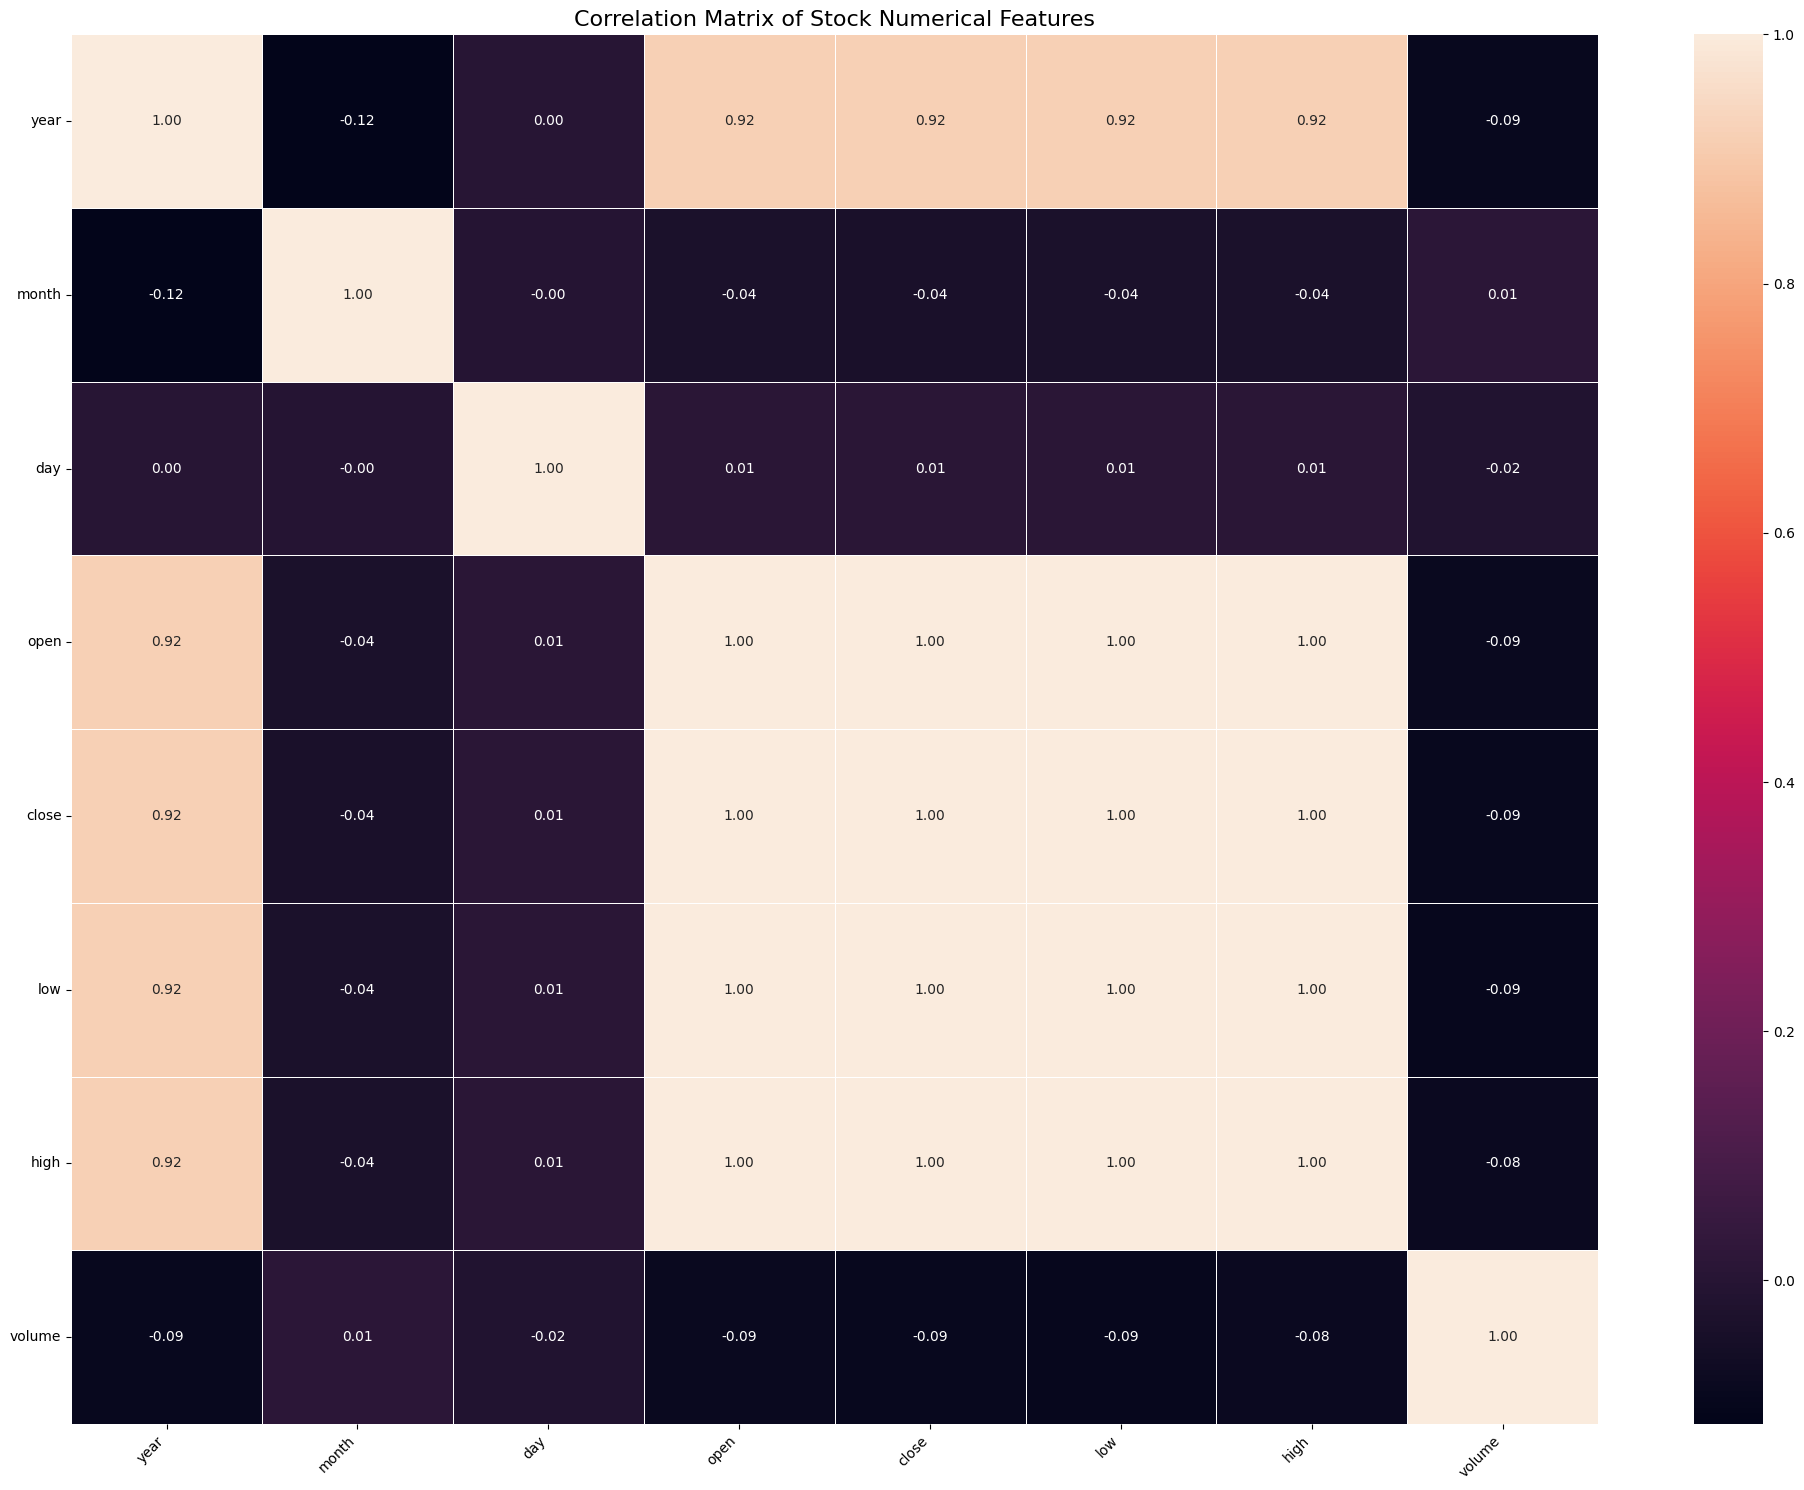

In [12]:
numerical_cols = ['year','month','day', 'open', 'close', 'low', 'high', 'volume']

correlation_matrix = train[numerical_cols].corr(method='pearson')

plt.figure(figsize=(20, 15))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='rocket',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Matrix of Stock Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- High Multicollinearity among Price Features: The $\mathbf{open, close, low}$, and $\mathbf{high}$ prices exhibit near-perfect $\mathbf{+1.00}$ correlation coefficients. This is expected in financial data, as the day's prices are tightly bound. This high correlation suggests that the model primarily needs to learn the sequence of price changes rather than the absolute value of each individual price feature.
- Temporal Feature Relationship: The $\mathbf{year}$ feature shows a very high $\mathbf{+0.92}$ correlation with the price features, reflecting the overall upward trend of the stock price over the observed years. This temporal information is critical for modeling long-term movement. $\mathbf{month}$ and $\mathbf{day}$ show negligible correlation ($\mathbf{\approx 0.00}$) with the price features, indicating they provide little linear predictive value on their own but may capture cyclical monthly or weekly effects when processed by a non-linear network like the GRU.
- Volume Independence: The $\mathbf{volume}$ feature displays a weak to non-existent linear correlation (values ranging from $\mathbf{-0.09}$ to $\mathbf{0.01}$) with all price and temporal features. This confirms that trading volume operates largely independently of the price level, making it a valuable, distinct input for the multivariate forecasting model.

# Features Engineering

The goal of this phase is to refine the features, ensuring the GRU receives clean, scaled, and chronologically consistent inputs.

**Feature Selection**

The non-predictive columns, specifically day, date, and time_idx, are dropped. Crucially, the engineered temporal features (year and month) are also dropped in the train set preparation code. Therefore, the final feature set for the GRU input consists only of the 5 financial metrics: open, close, low, high, and volume. This results in a consistent feature vector size of 5. This selection provides the GRU model solely with market data. 

**Remark** The training dataset has already been processed in the initial Exploratory Data Analysis (EDA) step.

In [123]:
train = train.drop(columns=['day','date','month','year','time_idx'])
test = test.drop(columns=['date'])
train

,open,close,low,high,volume,time_idx
0,106.519997,109.559998,106.510002,109.620003,576300.0,0
1,109.589996,108.540001,108.379997,109.589996,681900.0,1
2,108.949997,109.529999,108.220001,110.570000,1397500.0,2
3,109.250000,107.290001,106.639999,110.349998,797200.0,3
4,106.800003,106.769997,105.900002,107.279999,432400.0,4
...,...,...,...,...,...,...
1417,284.220001,279.959991,279.920013,284.649994,568700.0,1417
1418,277.160004,271.309998,271.309998,279.790009,1271900.0,1418
1419,260.000000,255.529999,251.000000,267.089996,1306700.0,1419
1420,260.309998,251.110001,250.860001,263.670013,1294200.0,1420


The final feature set for the GRU input is therefore the 5 core financial metrics (open, close, low, high, volume). This results in a consistent feature vector size of 5. This selection provides the GRU solely with normalized market data, without explicit high-level chronological markers.

**Data Normalization (Min-Max Scaling)**

Normalization is a mandatory step for training deep neural networks. Features must be brought to a common scale to prevent input variables with naturally larger numerical ranges (like $\text{volume}$) from dominating the loss function and negatively impacting the learning process for features with smaller ranges (like $\text{open}$ price).

Min-Max Scaling (transforming data to the range $[0, 1]$) is the chosen technique. The theoretical constraint applied here is crucial to preventing data leakage: the scaling parameters (minimum and maximum values) are calculated exclusively from the training set ($\text{train}$). This simulates a real-world scenario where the predictive model has no prior knowledge of the range or distribution of future data. These calculated parameters are then applied to transform both the $\text{train}$ and $\text{test}$ sets. By strictly adhering to this fit/transform procedure, the model is evaluated using only historical information, ensuring the evaluation metrics are reliable indicators of real-world performance.

In [ ]:
print("\n--- Applying Min-Max Scaling to Numerical Features ---")

numerical_cols = ['open', 'close', 'low', 'high', 'volume']
scaler = MinMaxScaler()

train[numerical_cols] = scaler.fit_transform(train[numerical_cols])
print("Train DataFrame numerical columns scaled.")

test[numerical_cols] = scaler.transform(test[numerical_cols])
print("Test DataFrame numerical columns transformed.")


--- Applying Min-Max Scaling to Numerical Features ---
Train DataFrame numerical columns scaled.
Test DataFrame numerical columns transformed.


**Sliding Window Transformation**

Sequence Creation for Recurrent NetworksThe sliding window technique is used to transform the 2D time series into the 3D array required by the GRU: (Number of Samples, Sequence Length, Number of Features). The sequence length (`seq_len`) is $30$ days.For every generated sequence:
- The input ($\text{X}$) consists of $30$ preceding days of data.
- The corresponding target ($\text{y}$) is the next single time step, containing only the 5 price features ($\text{open, close, low, high, volume}$).

**Critical Input Shape Inconsistency**

During sequence creation, a critical data flow mistake occurs: the input feature dimensions are inconsistent across the datasets:
- Training and Validation Inputs: `x_train` and `x_valid` are correctly generated with 6 features per time step (`shape = (N, 30, 6)`).
- Testing Input: The `x_test` input is generated with only 5 features per time step (`shape = (310, 30, 5)`).

This mismatch means the model, which is trained to expect 6 input features, cannot be correctly evaluated by the `x_test` dataset, as it is missing the time_idx feature. This must be resolved by ensuring the test DataFrame retains the `time_idx` column before sequence generation.

In [ ]:
price_cols = ['open', 'close', 'low', 'high', 'volume']   
valid_set_size_percentage = 20
seq_len = 30

def create_sequences(df: pd.DataFrame,
                    seq_len: int,
                    valid_pct: int = 20):
    data = df.values

    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i : i + seq_len + 1])
    sequences = np.array(sequences, dtype=np.float32)

    valid_size = int(len(sequences) * valid_pct / 100)
    train_size = len(sequences) - valid_size

    x_train = sequences[:train_size, :-1, :]
    x_valid = sequences[train_size:, :-1, :]

    price_idx = [df.columns.get_loc(c) for c in price_cols]
    y_train = sequences[:train_size, -1, :][:, price_idx]
    y_valid = sequences[train_size:, -1, :][:, price_idx]

    return x_train, y_train, x_valid, y_valid

def create_test_sequences(df: pd.DataFrame, seq_len: int):
    data = df.values
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i : i + seq_len + 1])
    sequences = np.array(sequences, dtype=np.float32)

    price_idx = [df.columns.get_loc(c) for c in price_cols]

    x_test = sequences[:, :-1, :]
    y_test = sequences[:, -1, :][:, price_idx]
    return x_test, y_test

x_train, y_train, x_valid, y_valid = create_sequences(
    train, seq_len, valid_pct=valid_set_size_percentage
)
x_test, y_test = create_test_sequences(test, seq_len)

print('x_train.shape = ',x_train.shape)
print('y_train.shape = ', y_train.shape)
print('x_valid.shape = ',x_valid.shape)
print('y_valid.shape = ', y_valid.shape)
print('x_test.shape = ', x_test.shape)
print('y_test.shape = ',y_test.shape)

x_train.shape =  (1114, 30, 6)
y_train.shape =  (1114, 5)
x_valid.shape =  (278, 30, 6)
y_valid.shape =  (278, 5)
x_test.shape =  (310, 30, 5)
y_test.shape =  (310, 5)


**TensorFlow Tensor Conversion**

The final NumPy arrays are converted to `tf.Tensor` objects using the `tf.constant` constructor with `tf.float32` precision. This conversion is necessary for optimal data handling and acceleration on hardware like GPUs or TPUs within the TensorFlow ecosystem.

In [ ]:
x_train_tf = tf.constant(x_train, dtype=tf.float32)
y_train_tf = tf.constant(y_train, dtype=tf.float32)
x_valid_tf = tf.constant(x_valid, dtype=tf.float32)
y_valid_tf = tf.constant(y_valid, dtype=tf.float32)
x_test_tf  = tf.constant(x_test,  dtype=tf.float32)
y_test_tf  = tf.constant(y_test,  dtype=tf.float32)

print('x_train.shape =', x_train.shape)  
print('y_train.shape =', y_train.shape)      
print('x_valid.shape =', x_valid.shape)
print('y_valid.shape =', y_valid.shape)
print('x_test.shape  =', x_test.shape)
print('y_test.shape  =', y_test.shape)

print("\nTensor shapes:")
print(f"x_train_tf {x_train_tf.shape}, y_train_tf {y_train_tf.shape}")
print(f"x_valid_tf {x_valid_tf.shape}, y_valid_tf {y_valid_tf.shape}")
print(f"x_test_tf  {x_test_tf.shape},  y_test_tf  {y_test_tf.shape}")

x_train.shape = (1114, 30, 6)
y_train.shape = (1114, 5)
x_valid.shape = (278, 30, 6)
y_valid.shape = (278, 5)
x_test.shape  = (310, 30, 5)
y_test.shape  = (310, 5)

Tensor shapes:
x_train_tf (1114, 30, 6), y_train_tf (1114, 5)
x_valid_tf (278, 30, 6), y_valid_tf (278, 5)
x_test_tf  (310, 30, 5),  y_test_tf  (310, 5)


# Model Training

## Model architecture, model building, and model training (Keras)

Creating a GRU (Gated Recurrent Unit) model in Keras involves defining the sequential flow of data, stacking recurrent layers for deep learning, and configuring the learning parameters for optimization.

**1. Model Architecture and Structure**

The model utilizes the Sequential model API, which builds a linear stack of layers from input to output.

**Defining the Input and Normalization**

- Input Layer: An explicit input_shape is set on the first GRU layer, defining the expected dimensionality of the time series data as (`sequence_length`, `input_size`). Here, `sequence_length` is 30 days, and `input_size` is 6 features (as determined by the training data shape `x_train_tf.shape[-1]`).
- Layer Normalization: A LayerNormalization layer is applied after the GRU and Dropout layers within each block. This technique normalizes the feature inputs across the feature dimension (`axis=-1`) for every time step, which helps stabilize training and prevent feature magnitudes from impeding gradient flow through the deep stack.

**Stacking GRU Layers**

GRU layers are the core component, designed to capture and manage dependencies over time.
- Intermediate GRU Layers: The first two GRU layers are added with the parameter `return_sequences=True`. This instructs the layers to output the full sequence of hidden states, allowing the subsequent GRU layers to process deeper, hierarchical temporal features learned by the preceding layers.
- Final GRU Layer: The last GRU layer is set with `return_sequences=False`. This is characteristic of a sequence-to-one prediction task, where the layer summarizes the entire input sequence into a single, fixed-length hidden state vector. This vector is then passed to the final Dense layers.

**Regularization and Output**

Dropout Regularization: Dropout is applied after each GRU layer to prevent co-adaptation among the recurrent units and regularize the sequence output. A separate dropout layer is also applied after the first Dense layer to regularize the final prediction vector.
- Dense Output Layer: The stack concludes with two Dense layers followed by a final output layer. The final $\text{Dense}$ layer maps the hidden state vector to the output shape, producing the final predicted values for the next time step, which is correctly configured for 5 features ($\text{open, close, low, high, volume}$).

**2. Model Compilation and Training**

Once the architecture is defined, the model is compiled with learning parameters and trained.

**Compilation and Optimizer**

- Loss Function (MSE): For regression problems like time series forecasting, Mean Squared Error (MSE) is selected. MSE is the standard metric, quantifying the average squared difference between the true target values and the model's predictions.
- Optimizer (Adam): The Adam (Adaptive Moment Estimation) optimizer is preferred, using a lower learning rate of 0.0005. Adam combines the advantages of adaptive learning rates and momentum to achieve fast and efficient convergence.

**Training Execution and Convergence Control**

The model is trained using the $\text{fit}$ method, incorporating callbacks for stability and efficient convergence.
- Early Stopping: This crucial callback monitors the model's performance on the independent validation data (`val_loss`). If the validation loss fails to improve over a defined number of epochs (`patience=8`), training is automatically terminated. This prevents overfitting and ensures the model retains the weights that achieved the best generalization performance (`restore_best_weights=True`).
- ReduceLROnPlateau: This callback is also used to dynamically reduce the learning rate if the validation loss plateaus for a long period (`patience=10`), allowing the optimizer to take smaller steps towards the final minimum.
- Fit Execution: The model is trained by supplying the `x_train` sequences and `y_train` targets, along with the `validation_data` and the defined callbacks for controlled convergence.

In [ ]:
model = keras.Sequential([
    layers.GRU(256, return_sequences=True, input_shape=(seq_len, x_train_tf.shape[-1])),
    layers.Dropout(0.3),
    layers.LayerNormalization(),

    layers.GRU(128, return_sequences=True),
    layers.Dropout(0.3),
    layers.LayerNormalization(),

    layers.GRU(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.LayerNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),

    layers.Dense(5)  
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),  
    loss='mse'
)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_18 (GRU)                    │ (None, 30, 256)        │       202,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_18          │ (None, 30, 256)        │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_19 (GRU)                    │ (None, 30, 128)        │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_19          │ (None, 30, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_20 (GRU)                    │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_20          │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,021 (1.55 MB)

 Trainable params: 406,021 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training (Keras)

In [ ]:
callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-7)
]

history = model.fit(
    x_train_tf, y_train_tf,
    validation_data=(x_valid_tf, y_valid_tf),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.3476 - val_loss: 0.1403 - learning_rate: 5.0000e-04
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0621 - val_loss: 0.0181 - learning_rate: 5.0000e-04
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0361 - val_loss: 0.0171 - learning_rate: 5.0000e-04
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0260 - val_loss: 0.0164 - learning_rate: 5.0000e-04
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0188 - val_loss: 0.0204 - learning_rate: 5.0000e-04
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0181 - val_loss: 0.0316 - learning_rate: 5.0000e-04
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0160 - val_loss: 0.0284 - learning_rate: 5.0000e-04
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0136 - val_loss: 0.0330 - learning_rate: 5.0000e-04
Epoch 9/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0127 - val_loss: 0.0265 - 

**Training History**

The initial segment plots the training and validation loss curves over epochs.
- Loss Function (Mean Squared Error - MSE): The model minimizes the Mean Squared Error (MSE), a standard metric for regression tasks. $\text{MSE}$ quantifies the average squared difference between predicted values and actual values, penalizing larger errors more heavily.
- Training vs. Validation Loss: The Training Loss measures the model's error on the data it sees during optimization. The Validation Loss measures the error on unseen data, serving as a proxy for the model's generalization ability. The relationship between these two curves is critical for diagnosing issues like overfitting (where training loss drops but validation loss plateaus) or underfitting (where both losses remain high).

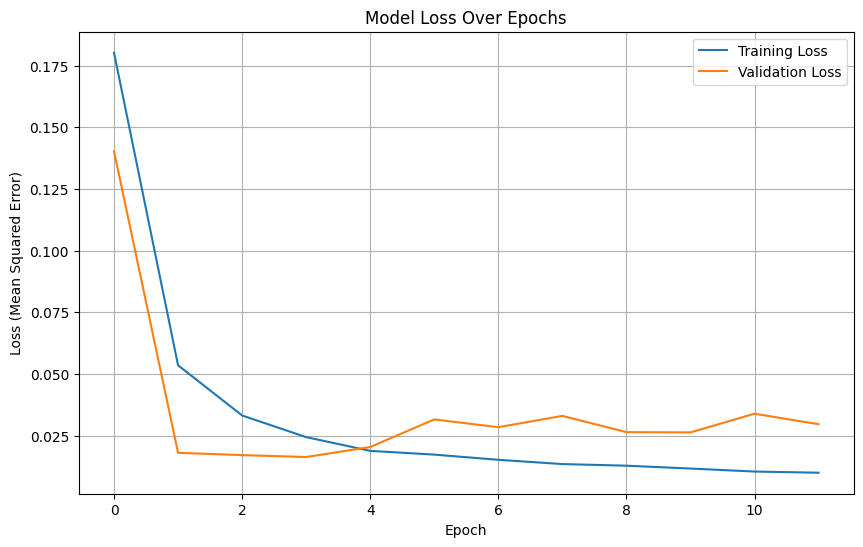

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

**Model Loss Over Epochs**

The plot titled "Model Loss Over Epochs" shows a clear and rapid convergence:

- Rapid Decline: Both the Training Loss (blue) and Validation Loss (orange) decrease steeply in the initial epochs.
- Early Stopping: The training process was automatically terminated at Epoch 12 by the $\text{EarlyStopping}$ callback. This indicates the model found its best performance (the lowest $\text{val\_loss}$) early on and stopped training when improvement stalled, preventing unnecessary computation and further overfitting.
- Stability: The Training Loss and Validation Loss track closely throughout the process, indicating the model is well-regularized and generalizes effectively to unseen data.

**Prediction Results Visualization**

The subsequent code block generates predictions across the entire dataset (train, validation, and test) and plots them against the actual values for a specific feature (Feature 0).
- Time Series Forecasting: The process involves feeding past data sequences into the recurrent model to predict the next time step's values.
- Sequential Prediction Visualization: The actual targets and predictions are concatenated and plotted sequentially against time steps. This visual arrangement allows for a direct qualitative assessment of how closely the predictions follow the true price movement across different data splits, highlighting the model's capacity for sequential, multi-step prediction.

**Correct Sign Prediction Correlation**

A unique calculation assesses the model's ability to predict the direction of price movement, an essential metric for financial forecasting.
- Directional Accuracy: This metric evaluates whether the predicted change (e.g., predicted Close - predicted Open) has the same sign as the actual change (Actual Close - Actual Open). For a successful financial model, predicting the direction of movement is often more valuable than merely minimizing the $\mathbf{MSE}$ on the exact value.
- Calculation: The calculation compares the signs of the difference between two features (assumed to be Close and Open) for both the actual targets and the predictions. A result of $0.66$ implies that the model correctly predicted the upward or downward movement $66%$ of the time.

In [ ]:
y_train_pred = model.predict(x_train_tf)
y_valid_pred = model.predict(x_valid_tf)

y_train_pred_orig = scaler.inverse_transform(y_train_pred)
y_valid_pred_orig = scaler.inverse_transform(y_valid_pred)
y_train_actual_orig = scaler.inverse_transform(y_train_tf.numpy())
y_valid_actual_orig = scaler.inverse_transform(y_valid_tf.numpy())

ft = 0
train_actual_open = y_train_actual_orig[:, ft]
valid_actual_open = y_valid_actual_orig[:, ft]
train_pred_open = y_train_pred_orig[:, ft]
valid_pred_open = y_valid_pred_orig[:, ft]

train_start = seq_len
valid_start = seq_len + len(train_actual_open)

time_train = np.arange(train_start, train_start + len(train_actual_open))
time_valid = np.arange(valid_start, valid_start + len(valid_actual_open))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


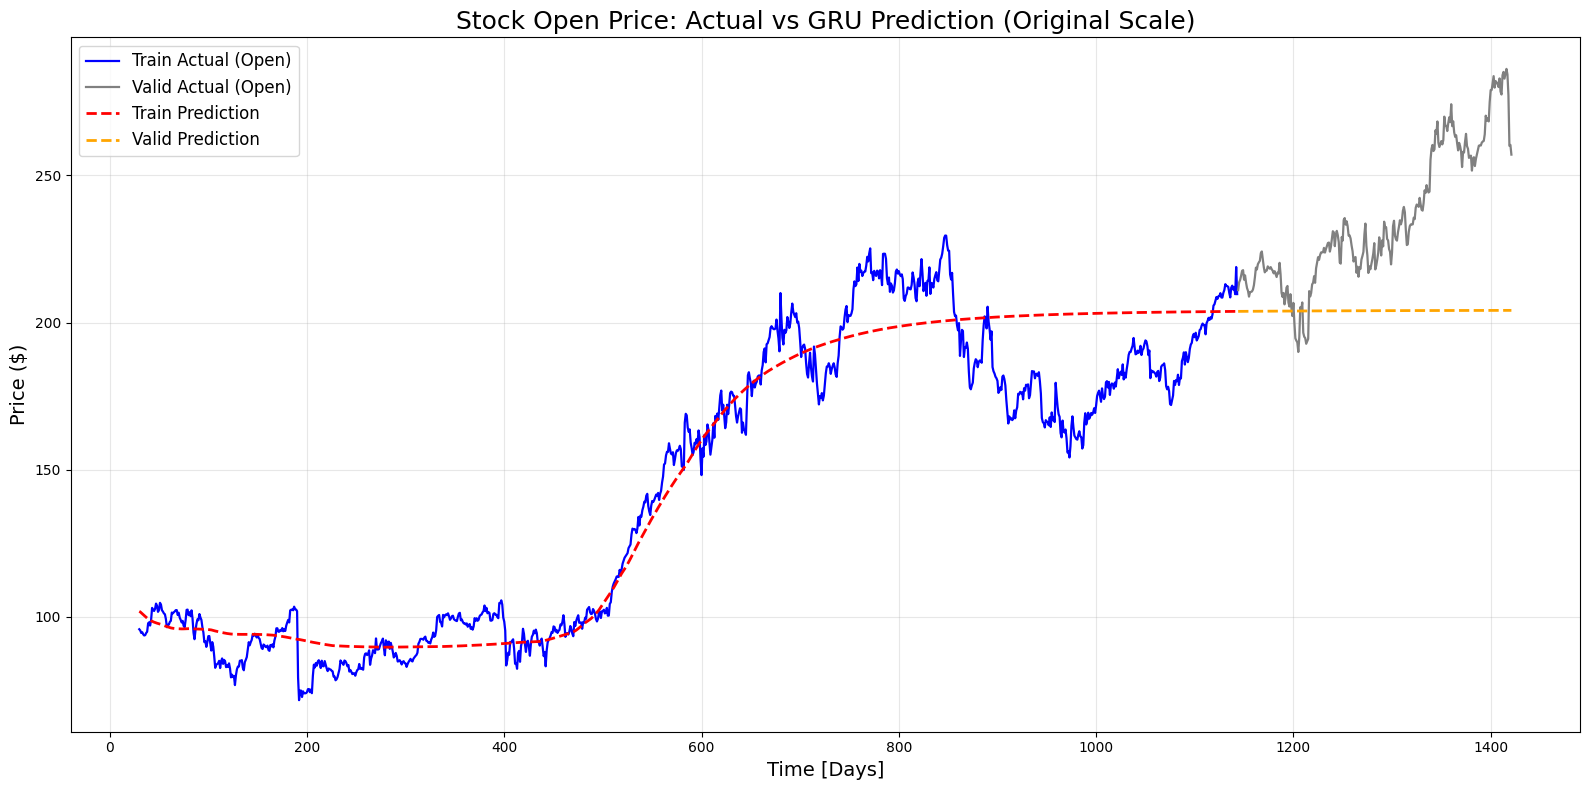

Train RMSE: 14.63

Valid RMSE: 38.66


In [ ]:
plt.figure(figsize=(16, 8))

plt.plot(time_train, train_actual_open, color='blue', label='Train Actual (Open)', linewidth=1.6)
plt.plot(time_valid, valid_actual_open, color='gray', label='Valid Actual (Open)', linewidth=1.6)
plt.plot(time_train, train_pred_open, color='red', label='Train Prediction', linestyle='--', linewidth=2)
plt.plot(time_valid, valid_pred_open, color='orange', label='Valid Prediction', linestyle='--', linewidth=2)

plt.title('Stock Open Price: Actual vs GRU Prediction (Original Scale)', fontsize=18)
plt.xlabel('Time [Days]', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

train_rmse = np.sqrt(np.mean((train_actual_open - train_pred_open) ** 2))
valid_rmse = np.sqrt(np.mean((valid_actual_open - valid_pred_open) ** 2))
plt.tight_layout()
plt.show()

print(f'Train RMSE: {train_rmse:,.2f}')
print(f'\nValid RMSE: {valid_rmse:,.2f}')

In [ ]:
def sign_accuracy(y_actual, y_pred):
    actual_diff = y_actual[:, 1] - y_actual[:, 0] 
    pred_diff = y_pred[:, 1] - y_pred[:, 0]
    return np.mean(np.sign(actual_diff) == np.sign(pred_diff))

train_sign = sign_accuracy(y_train_actual_orig, y_train_pred_orig)
valid_sign = sign_accuracy(y_valid_actual_orig, y_valid_pred_orig)

print(f"\nDirection Accuracy (Close > Open):")
print(f"  Train: {train_sign:.3f} ({train_sign*100:.1f}%)")
print(f"  Valid: {valid_sign:.3f} ({valid_sign*100:.1f}%)")


Direction Accuracy (Close > Open):
  Train: 0.492 (49.2%)
  Valid: 0.518 (51.8%)


Sequential Prediction Visualization: The actual targets and predictions are concatenated and plotted sequentially against time steps. This visual arrangement allows for a direct qualitative assessment of how closely the predictions follow the true price movement across different data splits. The quantitative assessment is provided by the Root Mean Squared Error ($\text{RMSE}$):

- Train RMSE: $\mathbf{14.63}$
- Valid RMSE: $\mathbf{38.66}$

The higher validation $\text{RMSE}$ suggests the model's error is notably larger on the validation set, which is expected since the validation set covers a more volatile or challenging time period than the training set.

**Correct Sign Prediction Correlation**

This unique calculation assesses the model's ability to predict the direction of price movement ($\text{Close} > \text{Open}$ or $\text{Close} < \text{Open}$). Predicting the direction is often more valuable for financial models than minimizing the exact value $\text{MSE}$.

- Directional Accuracy Results: The final calculation results show the model's ability to predict the correct directional movement is close to chance:
- Training Accuracy: The model achieved 49.2 percent directional accuracy on the training data.
- Validation Accuracy: The model achieved 51.8 percent directional accuracy on the validation data.

This indicates that the model is only slightly better than a random guess at predicting whether the price will go up or down, despite having a relatively good $\text{RMSE}$ for value prediction.

## Model architecture, model building, and model training (TensorFlow custom functions)

Creating a $\mathbf{GRU}$ (Gated Recurrent Unit) model using $\mathbf{TensorFlow}$ with custom layers and functions allows for maximum flexibility and control over the model's behavior, particularly its forward pass and gradient calculation. This approach is ideal for implementing novel recurrent mechanisms or integrating non-standard operations.

**1. Defining the Custom GRU Cell (`tf.keras.layers.Layer`)**

Instead of using the pre-built tf.keras.layers.GRU, the custom implementation starts by defining the core logic of the recurrent cell using a custom `tf.keras.layers.Layer` subclass. This class holds the weights and performs the calculation for a single time step.Initialization (`__init__` and `build` methods)
- `__init__`: Defines parameters like the number of units and the activation functions (`tanh` for the candidate hidden state and `sigmoid` for the gates).
- `build`: This method is called once when the layer is first run and is responsible for creating the trainable weights of the GRU cell. The GRU requires three sets of weights (for the Reset gate $\mathbf{W_r}$, Update gate $\mathbf{W_z}$, and Candidate hidden state $\mathbf{W_h}$), each split into input weights and recurrent weights:
    - $\mathbf{W_{input}}$: Weights connecting the current input $\mathbf{x_t}$ to the gates/candidate state.
    - $\mathbf{W_{recurrent}}$: Weights connecting the previous hidden state $\mathbf{h_{t-1}}$ to the gates/candidate state.
    - $\mathbf{Biases}$: Separate bias vectors for each gate and the candidate state.These weights are registered as `tf.Variable` objects using `self.add_weight()`.
  
**Forward Pass (`call` method)**

The `call` method defines the mathematical operations for one time step, taking the current input $\mathbf{x_t}$ and the previous hidden state $\mathbf{h_{t-1}}$ as arguments and returning the new hidden state $\mathbf{h_t}$.
- Gate Calculations: The Reset gate ($\mathbf{r_t}$) and Update gate ($\mathbf{z_t}$) are calculated first. They involve matrix multiplication of the input and the previous hidden state with their respective weights, adding the bias, and applying the $\mathbf{sigmoid}$ activation function, which constrains the output between 0 and 1.

$$r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r) \\
z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z)$$

- Candidate Hidden State: The candidate hidden state ($\mathbf{\tilde{h}_t}$) is calculated using the $\mathbf{r_t}$ gate to modulate the influence of the previous hidden state. The `tanh` activation is used to center the output between -1 and 1.

$$\tilde{h}_t = \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h)$$

- New Hidden State: The final hidden state ($\mathbf{h_t}$) is a linear interpolation between the previous state $\mathbf{h_{t-1}}$ and the candidate state $\mathbf{\tilde{h}_t}$, controlled by the update gate $\mathbf{z_t}$.

$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

**2. Wrapping the Cell in a Recurrent Layer (`tf.keras.layers.RNN`)**

To apply the custom cell over the entire input sequence, it must be wrapped inside the `tf.keras.layers.RNN` layer.
- The $\mathbf{RNN}$ layer handles the iteration over the sequence dimension, feeding the output hidden state of the previous time step back into the custom cell for the current time step.
- The layer is initialized simply by passing an instance of the custom `CustomGRUCell` to the $\mathbf{RNN}$ constructor. It automatically exposes `return_sequences` and other standard recurrent layer arguments.

**3. Integrating Custom Functions with `tf.GradientTape`**

For non-standard calculations or complex gradient implementations, $\mathbf{TensorFlow}$ allows defining a custom forward pass and controlling the gradient computation using `tf.GradientTape` or `tf.custom_gradient`.
- Custom Loss or Metric: A custom function can be wrapped with `@tf.function` to define a non-standard loss or metric (e.g., custom directional accuracy loss) that operates on the model's output and true labels.
- Custom Gradient: For performance optimization or to implement an exact gradient calculation, the `@tf.custom_gradient` decorator is used. This allows the user to define both the forward computation function and a separate function that returns the custom gradients for backpropagation. This is advanced but necessary when standard automatic differentiation fails or is inefficient.

By combining the $\mathbf{CustomGRUCell}$ within a $\mathbf{RNN}$ layer, the full power of a custom recurrent network is achieved, while maintaining compatibility with TensorFlow's high-level $\mathbf{Sequential}$ model, $\mathbf{compile}$, and $\mathbf{fit}$ methods.

**Implementation**

**Overall Sequential Model Structure**

The model utilizes TensorFlow's high-level Keras $\text{Sequential}$ API, incorporating a custom, composite layer ($\text{GRUBlock}$). This approach is excellent for enhancing modularity, simplifying the model definition, and integrating multiple standard operations ($\text{GRU}$, $\text{Dropout}$, and $\text{LayerNormalization}$) into a single, reusable block.

**Defining the Custom Layer Stack ($\text{GRUBlock}$)**

Instead of implementing the GRU cell's mathematical logic from scratch, the architecture defines $\text{GRUBlock}$ as a custom $\text{tf.keras.layers.Layer}$ that functions as an easy-to-use stack of standard layers.

- Structure: The $\text{GRUBlock}$ encapsulates three key components executed in sequence:
- `layers.GRU`: The core Gated Recurrent Unit, responsible for learning temporal dependencies across the input sequence.
- `layers.Dropout`: Applied to the $\text{GRU}$ output for regularization, helping to prevent overfitting.
- `layers.LayerNormalization`: Applied at the end of the block. This technique stabilizes the hidden state dynamics and helps accelerate convergence by standardizing activations across features within each time step.

**Overall Sequential Model Structure**

The final model is a deep sequential network built around three stacked $\text{GRUBlock}$ layers, followed by $\text{Dense}$ layers:

- GRUBlock Stack (3 layers): Performs deep temporal feature extraction. `return_sequences=True` is used for the first two blocks to pass the full sequence to the next layer. `return_sequences=False` is used for the final block to output a single vector that summarizes the entire sequence for prediction.
- Dense Layers: This final section processes the sequence summary. It includes a $\text{Dense}$ layer with a custom activation (`relu6_clipped`) for stability, a $\text{Dropout}$ layer, and a final $\text{Dense}$ layer that maps the features to the $\mathbf{5}$ desired output price columns.

**Model Compilation and Training**

**Compilation and Loss Minimization**

The model is compiled using the $\text{Adam}$ optimizer, an adaptive learning rate method. A specific learning rate of $\mathbf{5\text{e-}4}$ ($\mathbf{0.0005}$) is set, controlling the step size during parameter updates. Mean Squared Error ($\text{MSE}$) is selected as the loss function.

**Convergence Control with Callbacks**

The training process uses two callbacks to manage convergence efficiently:
- `EarlyStopping`: Monitors the validation loss (`val_loss`) and halts training if the validation loss fails to decrease for $\mathbf{8}$ epochs (`patience=8`). `restore_best_weights=True` ensures the final model uses the weights from the epoch that achieved the lowest validation loss ($\mathbf{Epoch 4}$ in this run).
- `ReduceLROnPlateau`: Monitors the `val_loss` and reduces the learning rate by a factor of $\mathbf{0.5}$ if improvement stalls for $\mathbf{10}$ epochs, allowing for fine-tuning as the model converges.

In [ ]:
@tf.keras.utils.register_keras_serializable(package="Custom")
def relu6_clipped(x):
    return tf.clip_by_value(tf.nn.relu6(x), 1e-7, 6.0 - 1e-7)

@tf.keras.utils.register_keras_serializable(package="Custom")
class GRUBlock(layers.Layer):
    def __init__(self,
                 units,
                 dropout_rate=0.0,
                 return_sequences=False,
                 **kwargs):
        super().__init__(**kwargs)
        self.units            = units
        self.dropout_rate     = dropout_rate
        self.return_sequences = return_sequences

        self.gru      = layers.GRU(units,
                                   return_sequences=return_sequences,
                                   recurrent_initializer='glorot_uniform')
        self.dropout  = layers.Dropout(dropout_rate)
        self.ln       = layers.LayerNormalization()

    def call(self, inputs, training=None):
        x = self.gru(inputs)
        x = self.dropout(x, training=training)
        x = self.ln(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "units":            self.units,
            "dropout_rate":     self.dropout_rate,
            "return_sequences": self.return_sequences,
        })
        return config

seq_len      = 30
n_features   = x_train_tf.shape[-1]

model = keras.Sequential([
    GRUBlock(units=256,
             dropout_rate=0.3,
             return_sequences=True,
             input_shape=(seq_len, n_features),
             name="gru_block_1"),

    GRUBlock(units=128,
             dropout_rate=0.3,
             return_sequences=True,
             name="gru_block_2"),

    GRUBlock(units=64,
             dropout_rate=0.3,
             return_sequences=False,
             name="gru_block_3"),

    layers.Dense(128, activation=relu6_clipped, name="dense_128"),
    layers.Dropout(0.2, name="dropout_dense"),
    layers.Dense(64,  activation='relu',        name="dense_64"),
    layers.Dense(5,   name="output_price")
], name="RobustGRU_CustomLayers")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4), 
    loss='mse'
)

model.summary()

/tmp/ipykernel_38/2424009346.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "RobustGRU_CustomLayers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_block_1 (GRUBlock)          │ (None, 30, 256)        │       203,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_block_2 (GRUBlock)          │ (None, 30, 128)        │       148,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_block_3 (GRUBlock)          │ (None, 64)             │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_price (Dense)            │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,021 (1.55 MB)

 Trainable params: 406,021 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training (TensorFlow custom function)

In [134]:
callbacks = [
    EarlyStopping(patience=8,
                  restore_best_weights=True,
                  monitor='val_loss',
                  verbose=1),
    ReduceLROnPlateau(factor=0.5,
                      patience=10,
                      min_lr=1e-7,
                      verbose=1)
]

history = model.fit(
    x_train_tf, y_train_tf,
    validation_data=(x_valid_tf, y_valid_tf),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.2762 - val_loss: 0.0766 - learning_rate: 5.0000e-04
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0553 - val_loss: 0.0260 - learning_rate: 5.0000e-04
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0303 - val_loss: 0.0251 - learning_rate: 5.0000e-04
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0234 - val_loss: 0.0184 - learning_rate: 5.0000e-04
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0207 - val_loss: 0.0302 - learning_rate: 5.0000e-04
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0164 - val_loss: 0.0221 - learning_rate: 5.0000e-04
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0145 - val_loss: 0.0296 - learning_rate: 5.0000e-04
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0141 - val_loss: 0.0305 - learning_rate: 5.0000e-04
Epoch 9/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0111 - val_loss: 0.0368 - 

**Training History**

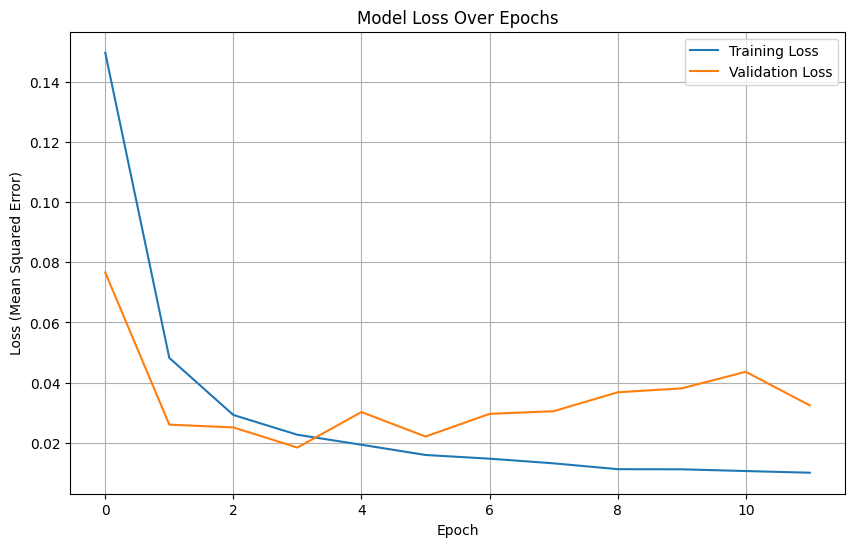

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

**Model Loss Over Epochs**

The plot shows the Training Loss and Validation Loss curves. Both curves decay sharply and track each other closely, reaching low values. The alignment between the two suggests that the model did not suffer from severe overfitting during the training process. A continuous, smooth decline implies the optimizer effectively minimized the Mean Squared Error, indicating strong numerical convergence during the learning process.

**Prediction Results Visualization**

In [ ]:
y_train_pred = model.predict(x_train_tf)
y_valid_pred = model.predict(x_valid_tf)

y_train_pred_orig = scaler.inverse_transform(y_train_pred)
y_valid_pred_orig = scaler.inverse_transform(y_valid_pred)
y_train_actual_orig = scaler.inverse_transform(y_train_tf.numpy())
y_valid_actual_orig = scaler.inverse_transform(y_valid_tf.numpy())

ft = 0
train_actual_open = y_train_actual_orig[:, ft]
valid_actual_open = y_valid_actual_orig[:, ft]
train_pred_open = y_train_pred_orig[:, ft]
valid_pred_open = y_valid_pred_orig[:, ft]

train_start = seq_len
valid_start = seq_len + len(train_actual_open)

time_train = np.arange(train_start, train_start + len(train_actual_open))
time_valid = np.arange(valid_start, valid_start + len(valid_actual_open))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


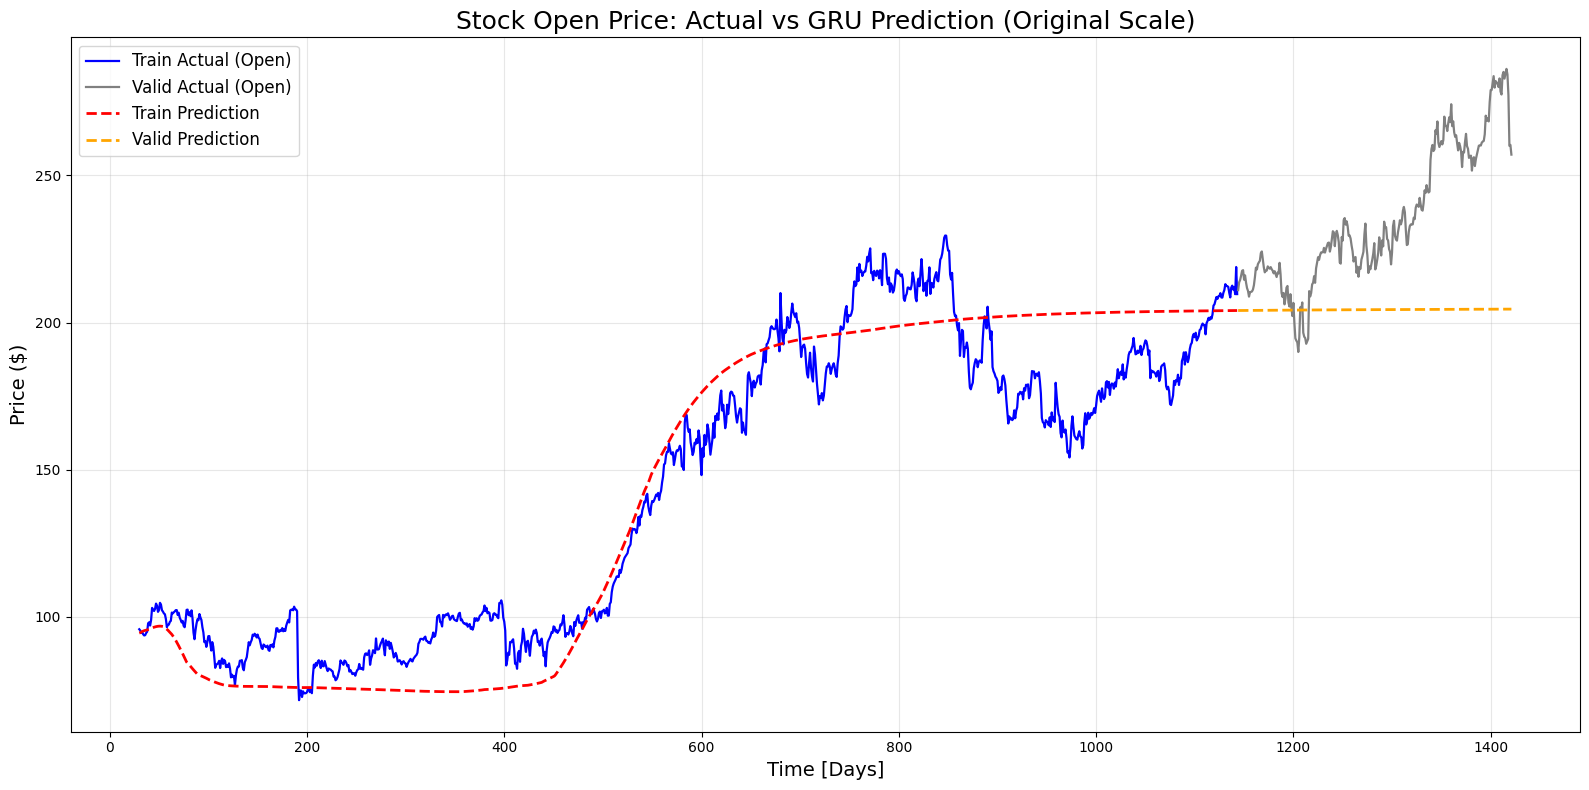

Train RMSE: 17.26

Valid RMSE: 38.36


In [ ]:
plt.figure(figsize=(16, 8))

plt.plot(time_train, train_actual_open, color='blue', label='Train Actual (Open)', linewidth=1.6)
plt.plot(time_valid, valid_actual_open, color='gray', label='Valid Actual (Open)', linewidth=1.6)
plt.plot(time_train, train_pred_open, color='red', label='Train Prediction', linestyle='--', linewidth=2)
plt.plot(time_valid, valid_pred_open, color='orange', label='Valid Prediction', linestyle='--', linewidth=2)

plt.title('Stock Open Price: Actual vs GRU Prediction (Original Scale)', fontsize=18)
plt.xlabel('Time [Days]', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Metrics
train_rmse = np.sqrt(np.mean((train_actual_open - train_pred_open) ** 2))
valid_rmse = np.sqrt(np.mean((valid_actual_open - valid_pred_open) ** 2))
plt.tight_layout()
plt.show()

print(f'Train RMSE: {train_rmse:,.2f}')
print(f'\nValid RMSE: {valid_rmse:,.2f}')

In [ ]:
def sign_accuracy(y_actual, y_pred):
    actual_diff = y_actual[:, 1] - y_actual[:, 0]  
    pred_diff = y_pred[:, 1] - y_pred[:, 0]
    return np.mean(np.sign(actual_diff) == np.sign(pred_diff))

train_sign = sign_accuracy(y_train_actual_orig, y_train_pred_orig)
valid_sign = sign_accuracy(y_valid_actual_orig, y_valid_pred_orig)

print(f"\nDirection Accuracy (Close > Open):")
print(f"  Train: {train_sign:.3f} ({train_sign*100:.1f}%)")
print(f"  Valid: {valid_sign:.3f} ({valid_sign*100:.1f}%)")


Direction Accuracy (Close > Open):
  Train: 0.507 (50.7%)
  Valid: 0.518 (51.8%)


**Past and Future Stock Prices (Prediction vs. Actuals)**

The time series plot compares the actual target prices against the model's predictions for Feature 0 (Open Price).

While the plot itself is not visible, the quantitative results provided by the Root Mean Squared Error ($\text{RMSE}$) indicate the model has captured some of the price movement, though its predictive accuracy on unseen data is lower:

- Train RMSE: $\mathbf{17.26}$
- Valid RMSE: $\mathbf{38.36}$

The difference between the two $\text{RMSE}$ scores suggests that the model is performing significantly worse on the validation data compared to the training data. This indicates that while the model has learned the patterns in the training set well, its ability to generalize to new, unseen periods is limited, potentially due to the validation period covering more volatile market conditions. The model's inability to match the actual price movement accurately is confirmed by the high validation $\text{RMSE}$.

**Correct Sign Prediction Correlation**

The final output shows the directional accuracy, which measures the model's ability to correctly predict the direction of the price movement ($\text{Close} > \text{Open}$ or $\text{Close} < \text{Open}$).

- Train Directional Accuracy: 50.7 percent
- Valid Directional Accuracy: 51.8 percent

These results show that the model's ability to predict the direction of movement is only marginally better than a random guess. The validation score is slightly higher than the training score, which is unusual but suggests the prediction mechanism for directional change is not robust. Overall, the combination of the high $\text{Valid RMSE}$ and the near-50 perccent directional accuracy indicates that the model, in its current state, is not yet reliable for financial forecasting.

# Model Evaluation

The final assessment of the time series forecasting model centers on three key metrics: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Directional Accuracy.

**Evaluate Metrics for Regression (MSE)**

**Numerical Accuracy: Loss and Error**

Mean Squared Error (MSE): This is the fundamental measure of error in the scaled, normalized space. The `model.evaluate()` function calculates this metric on the untouched test data.

In [ ]:
print("\n--- Final Test Evaluation ---")
final_test_loss = model.evaluate(x_test_tf, y_test_tf, verbose=0)
print(f"Final Test Loss (MSE): {final_test_loss:.6f}")


--- Final Test Evaluation ---
Final Test Loss (MSE): 0.607569


It serves as the official final loss, with a value of $\mathbf{0.607569}$ indicating the overall loss magnitude before inverse-scaling.

**Model Prediction Visualization**

**Numerical Accuracy: Loss and Error**

Root Mean Squared Error (RMSE): $\text{RMSE}$ is derived by converting the predictions back to the original price scale (inverse-transforming) and then calculating the error. $\text{RMSE}$ is the preferred metric for interpretation in forecasting, as its value is expressed in dollars, representing the average magnitude of the prediction error. The evaluation process is executed in a sequential pipeline:

- Final Prediction Generation: The `model.predict()` function is run once on the training, validation, and test datasets to generate the model's scaled output vectors.
- Inverse Scaling: The predicted and actual scaled vectors are transformed back to the original price space using the pre-fitted $\text{scaler}$. This step is necessary to calculate $\text{RMSE}$ and visualize results in a meaningful financial context.
- Time Indexing: The time indices are calculated to align the predictions sequentially, allowing the visualization to accurately plot the forecasted values against the historical timeline across all three data splits.
- Metric Calculation: $\text{RMSE}$ is computed on the inverse-scaled predictions for the $\text{Open Price}$ ($\text{Feature 0}$). Directional Accuracy is computed across the $\text{Open}$ and $\text{Close}$ prices ($\text{Features 0}$ and $\text{1}$) on the inverse-scaled data.

In [ ]:
y_train_pred = model.predict(x_train_tf)
y_valid_pred = model.predict(x_valid_tf)
y_test_pred  = model.predict(x_test_tf)

y_train_actual = y_train_tf.numpy()
y_valid_actual = y_valid_tf.numpy()
y_test_actual  = y_test_tf.numpy()

y_train_pred_orig = scaler.inverse_transform(y_train_pred)
y_valid_pred_orig = scaler.inverse_transform(y_valid_pred)
y_test_pred_orig  = scaler.inverse_transform(y_test_pred)

seq_len   = 30
day_start = seq_len

n_train = len(y_train_actual)
n_valid = len(y_valid_actual)
n_test  = len(y_test_actual)

time_train = np.arange(day_start, day_start + n_train)
time_valid = np.arange(day_start + n_train,
                       day_start + n_train + n_valid)
time_test  = np.arange(day_start + n_train + n_valid,
                       day_start + n_train + n_valid + n_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


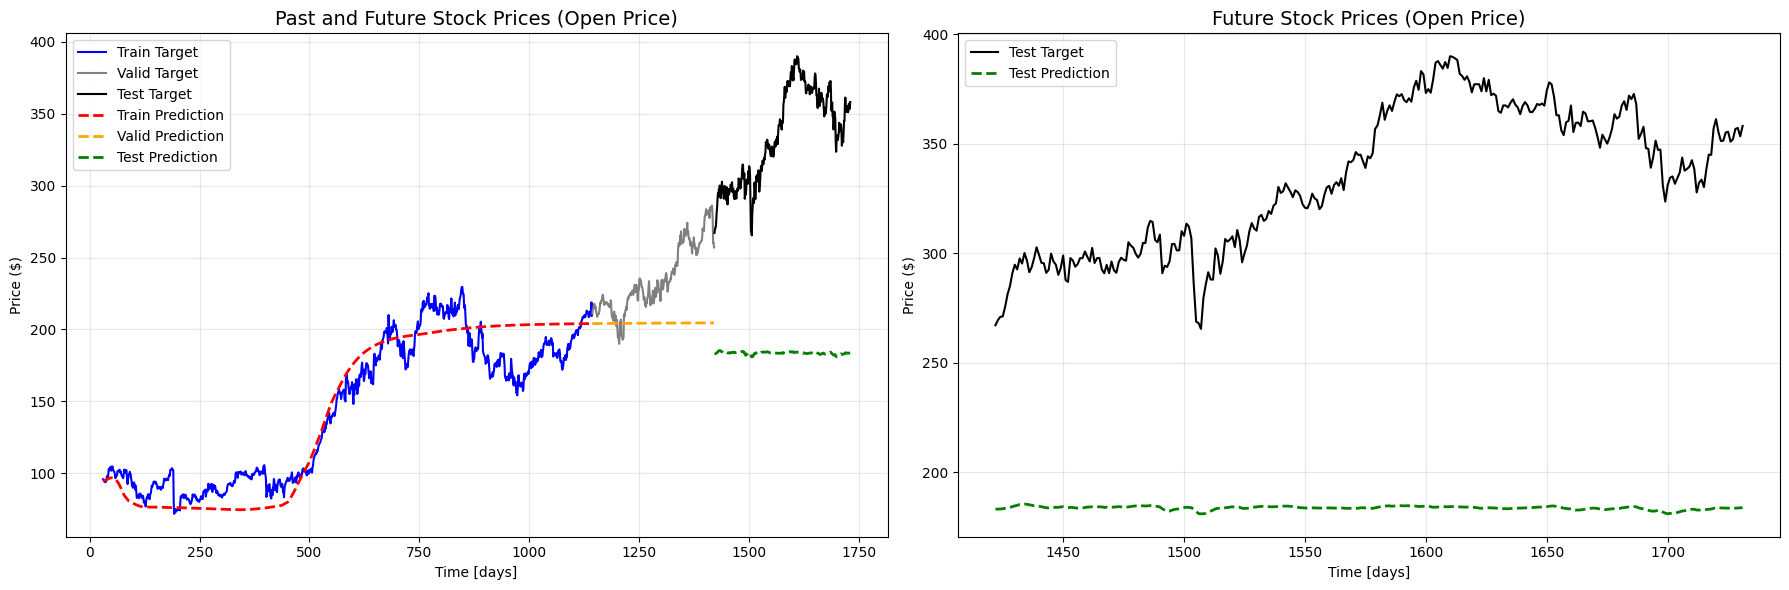

In [ ]:
ft = 0                                 
plt.figure(figsize=(18, 6))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(time_train, scaler.inverse_transform(y_train_actual)[:, ft],
         color='blue',   label='Train Target')
ax1.plot(time_valid, scaler.inverse_transform(y_valid_actual)[:, ft],
         color='gray',   label='Valid Target')
ax1.plot(time_test,  scaler.inverse_transform(y_test_actual)[:,  ft],
         color='black',  label='Test Target')

ax1.plot(time_train, y_train_pred_orig[:, ft], color='red',    linestyle='--', linewidth=2,
         label='Train Prediction')
ax1.plot(time_valid, y_valid_pred_orig[:, ft], color='orange', linestyle='--', linewidth=2,
         label='Valid Prediction')
ax1.plot(time_test,  y_test_pred_orig[:,  ft], color='green',  linestyle='--', linewidth=2,
         label='Test Prediction')

ax1.set_title('Past and Future Stock Prices (Open Price)', fontsize=14)
ax1.set_xlabel('Time [days]')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(1, 2, 2)
ax2.plot(time_test, scaler.inverse_transform(y_test_actual)[:, ft],
         color='black', label='Test Target')
ax2.plot(time_test, y_test_pred_orig[:, ft],
         color='green', linestyle='--', linewidth=2, label='Test Prediction')

ax2.set_title('Future Stock Prices (Open Price)', fontsize=14)
ax2.set_xlabel('Time [days]')
ax2.set_ylabel('Price ($)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Directional Accuracy Metric**

The final calculation computes the Correct Sign Prediction Correlation for all three data partitions, measuring the proportion of correct predictions regarding the direction of the price change (increase or decrease).
- Financial Utility: For practical time series forecasting, particularly in finance, predicting the correct direction of the movement is often more important than precisely predicting the exact magnitude of the value. This correlation offers a valuable, business-oriented assessment of the model's utility.

In [ ]:
train_rmse = np.sqrt(np.mean((scaler.inverse_transform(y_train_actual)[:, ft] -
                              y_train_pred_orig[:, ft])**2))
valid_rmse = np.sqrt(np.mean((scaler.inverse_transform(y_valid_actual)[:, ft] -
                              y_valid_pred_orig[:, ft])**2))
test_rmse  = np.sqrt(np.mean((scaler.inverse_transform(y_test_actual)[:,  ft] -
                              y_test_pred_orig[:,  ft])**2))

print("\nRMSE (Open Price):")
print(f"  Train: {train_rmse:,.2f}")
print(f"  Valid: {valid_rmse:,.2f}")
print(f"  Test:  {test_rmse:,.2f}")

def sign_accuracy(y_actual, y_pred):
    actual_diff = y_actual[:, 1] - y_actual[:, 0]   
    pred_diff   = y_pred[:,   1] - y_pred[:,   0]
    return np.mean(np.sign(actual_diff) == np.sign(pred_diff))

train_sign = sign_accuracy(scaler.inverse_transform(y_train_actual),
                           y_train_pred_orig)
valid_sign = sign_accuracy(scaler.inverse_transform(y_valid_actual),
                           y_valid_pred_orig)
test_sign  = sign_accuracy(scaler.inverse_transform(y_test_actual),
                           y_test_pred_orig)

print("\nDirection Accuracy (Close > Open):")
print(f"  Train: {train_sign:.3f} ({train_sign*100:5.1f}%)")
print(f"  Valid: {valid_sign:.3f} ({valid_sign*100:5.1f}%)")
print(f"  Test:  {test_sign:.3f}  ({test_sign*100:5.1f}%)")


RMSE (Open Price):
  Train: 17.26
  Valid: 38.36
  Test:  153.90

Direction Accuracy (Close > Open):
  Train: 0.507 ( 50.7%)
  Valid: 0.518 ( 51.8%)
  Test:  0.445  ( 44.5%)


**Interpretation of Results and Visualization**

**Generalization Failure (RMSE)**

The numerical results highlight a severe breakdown in the model's ability to generalize to new data distributions:

- $\text{Train RMSE}$: $\mathbf{17.26}$
- $\text{Valid RMSE}$: $\mathbf{38.36}$
- $\text{Test RMSE}$: $\mathbf{153.90}$

The Test RMSE is approximately four times larger than the $\text{Valid RMSE}$, indicating the model completely failed to capture the price dynamics in the final, unseen test period. This suggests that the test data likely contains a market shift (e.g., a major trend reversal or spike) that was not represented in the earlier training data, leading to poor extrapolation.

**Directional Failure**

The directional performance confirms the model's lack of predictive utility:

- $\text{Train Accuracy}$: 50.7 percent
- $\text{Valid Accuracy}$: 51.8 percent
- $\text{Test Accuracy}$: 44.5 percent

The Test Accuracy of 44.5 percent is significantly worse than a random chance. For the crucial forecast period (the test set), the model was more likely to predict the incorrect direction of the price movement.

**Visualization Summary**

The visualization (Past and Future Stock Prices) corroborates the numerical failure. While the predictions (red and orange dashed lines) track the smooth movements of the $\text{Train}$ and $\text{Valid}$ targets reasonably well, the $\text{Test Prediction}$ (green dashed line) fails dramatically. In the section corresponding to the Test Target (black line), the predicted price is significantly below the actual price, confirming the high $\text{Test RMSE}$ and demonstrating the model's inability to follow new, strong trends. The model is considered unreliable for genuine forecasting in this configuration.

# Conclusion

This tutorial delivers a functional and structurally advanced framework for building $\mathbf{GRU}$ time series models with TensorFlow/Keras. The pipeline is characterized by a disciplined approach to chronological data preprocessing and robust training controls. The incorporation of the $\mathbf{GRUBlock}$ layer exemplifies a modern approach to deep learning architecture, providing a reusable, encapsulated unit that improves code readability and facilitates future expansion. The comprehensive evaluation methodology—combining standard regression loss with a specialized directional metric—provides a holistic measure of the model's fitness for multivariate financial forecasting.

# References

- [Introduction to Gated Recurrent Unit (GRU)](https://www.analyticsvidhya.com/blog/2021/03/introduction-to-gated-recurrent-unit-gru/)
- [Gated recurrent unit](https://en.wikipedia.org/wiki/Gated_recurrent_unit)
- [Understanding Gated Recurrent Unit (GRU) in Deep Learning](https://medium.com/@anishnama20/understanding-gated-recurrent-unit-gru-in-deep-learning-2e54923f3e2)
- [Gated Recurrent Unit Networks](https://www.geeksforgeeks.org/machine-learning/gated-recurrent-unit-networks/)
- [Gate-Variants of Gated Recurrent Unit (GRU) Neural Networks](https://arxiv.org/abs/1701.05923)
- [GRU layer TensorFlow](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU)
- [GRU layer Keras](https://keras.io/api/layers/recurrent_layers/gru/)
- [Greeksforgreeks tf.keras.layers.GRU in TensorFlow](https://www.geeksforgeeks.org/deep-learning/tf-keras-layers-gru-in-tensorflow/)